### A script for generating loops for every chromosome and combining them into a single array and plotting
### Two genomes are plotted on the same plot (genuine and pseudo)

In [1]:
import re
import numpy as np
import pandas as pd
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import os
import itertools
import math
from Bio.SeqIO.FastaIO import FastaIterator
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from collections import Counter
import random
from Bio import SeqIO

In [ ]:
"""
Search patterns for exact and degenerate Tel repeats
"""

# patternG = "TTAGGG"
# patternC = "CCCTAA"

patternG = "T{1,2}A{0,1}G{3,5}|T{1,2}\D{1}A{1}G{3,5}|T{2}A{1}G{2}"
patternC = "C{3,5}T{0,1}A{1,2}|C{3,5}T{1}\D{1}A{1,2}|C{2}T{1}A{2}"

patternG_obj = re.compile(patternG)
patternC_obj = re.compile(patternC)

In [ ]:
filename1 = '240404_T2Tv2_genome_ncbi_dataset/ncbi_dataset/data/GCF_009914755.1/GCF_009914755.1_T2T-CHM13v2.0_genomic.fna'

In [ ]:
filename2 = 'D:/Documents/Documents/SPB_work/ITSs/Genomes/240630_human_pseudo_genome.fna'

In [ ]:
output_file = 'FuzzyTel_loop_occurence_genuine_vs_pseudo_whole_genome_median.pdf'

In [6]:
#Parsing fasta 
def fasta_reader(infile):
    with open(infile) as handle:
        for record in FastaIterator(handle):
            yield record

In [ ]:
def save_image(file, fig_list):

    pdf = PdfPages(file)

    for fig in fig_list: 
        fig.savefig(pdf, format='pdf') 
          
    pdf.close()  

In [8]:
def search_functionGC(myseq, pattern):
    ind_spans = [match.span() for match in re.finditer(pattern, myseq)]

    ind_start=[span[0] for span in ind_spans]
    ind_end=[span[1] for span in ind_spans]

    return ind_start, ind_end

In [ ]:
def loop_function(myseq, start, end):
    """Determines the loop lengths between repeats"""

    ind_start = np.array(start)
    ind_end = np.array(end)
    sequence_length = len(myseq)

    if len(ind_start)>0:
        loop_list = np.subtract(ind_start[1:], ind_end[:-1])
        start_loop = ind_start[0]
        end_loop = sequence_length -ind_end[-1]
        
        loop_list_left_tail = np.insert(loop_list, 0, start_loop)
        loop_list_arr = np.append(loop_list_left_tail, end_loop)

    return loop_list_arr


In [10]:
from matplotlib.ticker import LogLocator
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator

In [ ]:
def image_loops_multifasta(loop_list_arrG, loop_list_arrC, pseudo_loop_list_arrG, pseudo_loop_list_arrC, genuine_description, pseudo_description, loops_map):
    
    # patternG = 'FuzzyTel, G-orientation'
    # patternC = 'FuzzyTel, C-orientation'
    uniqueG, countsG = np.unique(loop_list_arrG, return_counts=True)
    uniqueC, countsC = np.unique(loop_list_arrC, return_counts=True)
    # Adding a small constant to x_values to shift zero to a very small positive number
    uniqueG_forlog = np.where(uniqueG == 0, 0.1, uniqueG)
    uniqueC_forlog = np.where(uniqueC == 0, 0.1, uniqueC)
    ##I need to change the font of description, it is too large
    pseudo_uniqueG, pseudo_countsG = np.unique(pseudo_loop_list_arrG, return_counts=True)
    pseudo_uniqueC, pseudo_countsC = np.unique(pseudo_loop_list_arrC, return_counts=True)
    # Adding a small constant to x_values to shift zero to a very small positive number
    pseudo_uniqueG_forlog = np.where(pseudo_uniqueG == 0, 0.1, pseudo_uniqueG)
    pseudo_uniqueC_forlog = np.where(pseudo_uniqueC == 0, 0.1, pseudo_uniqueC)


    def fig1():
        fig1, (ax1, ax2) = plt.subplots(2,1, sharex=True, figsize=(6, 6))
        #ax1.set_title(f'{description} \n\n pattern "{patternG}"', fontsize=6)
        #ax1.set_title(f'{genuine_description} \n {pseudo_description} \n\n pattern "{patternG}"', fontsize=6)
        ax1.set_title(f'pattern {patternG}', fontsize=12)
        ax1.scatter(uniqueG_forlog, countsG, label='LoopG natural', color='royalblue', s=2, alpha=0.4)
        ax1.scatter(pseudo_uniqueG_forlog, pseudo_countsG, label='LoopG pseudo', color='aquamarine', s=1, alpha=0.4)
        ax1.legend()
        #plt.xlabel("Loop length, log scale")
        #ax1.yaxis.set_major_formatter(FormatStrFormatter('% 1.0f')) 
        ax1.tick_params(axis='y', which='major', labelsize=10)
        #ax1.tick_params(axis='x', which='minor', colors='black')
        ax1.xaxis.set_minor_locator(AutoMinorLocator(9)) 
        ax1.set_xscale('log') 
        ax1.set_yscale('log') 
        # ax1.set_ylabel("Occurence, log scale")
        
        #ax2.set_title(f'pattern "{patternC}"', fontsize=6)
        ax2.set_title(f'pattern {patternC}', fontsize=12)
        ax2.scatter(uniqueC_forlog, countsC, label='LoopC natural', color='seagreen', s=2, alpha=0.4)
        ax2.scatter(pseudo_uniqueC_forlog, pseudo_countsC, label='LoopC pseudo', color='aquamarine', s=1, alpha=0.4)
        ax2.legend()
        plt.xlabel("Loop length, log scale", fontsize=14)
        
        #ax2.yaxis.set_major_formatter(FormatStrFormatter('% 1.0f')) 
        ax2.tick_params(axis='y', which='major', labelsize=10)
        #ax2.tick_params(axis='x', which='minor', colors='black')
        ax2.xaxis.set_minor_locator(AutoMinorLocator(9)) 
        ax2.set_xscale('log')
        ax2.set_yscale('log')   
        # ax2.set_ylabel("Occurence, log scale", fontsize=14)

        ticks = [0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]
        ax1.set_xticks(ticks)
        ax2.set_xticks(ticks)

        # Define custom labels, labeling 0.1 as '0'
        labels = ['0', '1', '10', '100', '1000', '10000', ' 100000', '  1000000']
        ax1.set_xticklabels(labels)
        ax2.set_xticklabels(labels)
        
    
        fig1.text(0.010, 0.5, "Occurrence, log scale", ha="center", va="center", rotation=90, fontsize=14)
        fig1.suptitle('Loop lengths occurence')
        fig1.tight_layout()
        
        return fig1

    figure1 = fig1()
    loops_map.append(figure1)
    return loops_map

In [ ]:
def genuine_genome(entry, patternG_obj, patternC_obj):
    
    seqname = entry.id
    seq = entry.seq
    description = entry.description
    ###Code for the complete genome###
    print(description)
    # print(len(seq))
    myseq = str(seq).replace(' ', '').upper()
    print(len(myseq))

    

    resultG = search_functionGC(myseq, patternG_obj)
    resultC = search_functionGC(myseq, patternC_obj)
    ind_startG = resultG[0]
    ind_endG = resultG[1]
    ind_startC = resultC[0]
    ind_endC = resultC[1]
    loop_list_arrG = loop_function(myseq, ind_startG, ind_endG)
    loop_list_arrC = loop_function(myseq, ind_startC, ind_endC)

    return loop_list_arrG, loop_list_arrC, description

In [ ]:
def pseudo_genome(entry, patternG_obj, patternC_obj):
    
    seqname = entry.id
    seq = entry.seq
    pseudo_description = entry.description
    print(pseudo_description)
    # print(len(seq))
    pseudo_seq = str(seq).replace(' ', '').upper()
    print(len(pseudo_seq))

    pseudo_resultG = search_functionGC(pseudo_seq, patternG_obj)
    pseudo_resultC = search_functionGC(pseudo_seq, patternC_obj)

    
    pseudo_ind_startG = pseudo_resultG[0]
    pseudo_ind_endG = pseudo_resultG[1]
    pseudo_ind_startC = pseudo_resultC[0]
    pseudo_ind_endC = pseudo_resultC[1]

    
    pseudo_loop_list_arrG = loop_function(pseudo_seq, pseudo_ind_startG, pseudo_ind_endG)
    pseudo_loop_list_arrC = loop_function(pseudo_seq, pseudo_ind_startC, pseudo_ind_endC)

    

    return pseudo_loop_list_arrG, pseudo_loop_list_arrC, pseudo_description

In [ ]:
def complete_prediction_multifasta(filename1, filename2, patternG_obj, patternC_obj):    
    loops_map = []
    loopsG_arr_genuine = []
    loopsC_arr_genuine = []
    loopsG_arr_pseudo = []
    loopsC_arr_pseudo = []

    pdf_loops_map = output_file

    fasta_reader1 = SeqIO.parse(filename1, "fasta")
    fasta_reader2 = SeqIO.parse(filename2, "fasta")


    for entry1, entry2 in zip(fasta_reader1, fasta_reader2):

        genuine_result = genuine_genome(entry1, patternG_obj, patternC_obj)
        pseudo_result = pseudo_genome(entry2, patternG_obj, patternC_obj)

        loop_list_arrG = genuine_result[0]
        loop_list_arrC = genuine_result[1]
        

        pseudo_loop_list_arrG = pseudo_result[0]
        pseudo_loop_list_arrC = pseudo_result[1]
        

        loopsG_arr_genuine.append(loop_list_arrG)
        loopsC_arr_genuine.append(loop_list_arrC)
        loopsG_arr_pseudo.append(pseudo_loop_list_arrG)
        loopsC_arr_pseudo.append(pseudo_loop_list_arrC)
        
   
    genuine_description = 'T2Tv2.0 whole genome'
    pseudo_description = 'pseudo genome'
    combined_arrayG_genuine = np.concatenate(loopsG_arr_genuine)
    combined_arrayC_genuine = np.concatenate(loopsC_arr_genuine)
    combined_arrayG_pseudo = np.concatenate(loopsG_arr_pseudo)
    combined_arrayC_pseudo = np.concatenate(loopsC_arr_pseudo)
    print('combined_arrayG_genuine mean', np.mean(combined_arrayG_genuine))
    print('combined_arrayC_genuine mean', np.mean(combined_arrayC_genuine))
    print('combined_arrayG_pseudo mean', np.mean(combined_arrayG_pseudo))
    print('combined_arrayC_pseudo mean', np.mean(combined_arrayC_pseudo))
    print('combined_arrayG_genuine median', np.median(combined_arrayG_genuine))
    print('combined_arrayC_genuine median', np.median(combined_arrayC_genuine))
    print('combined_arrayG_pseudo median', np.median(combined_arrayG_pseudo))
    print('combined_arrayC_pseudo median', np.median(combined_arrayC_pseudo))
    print('combined_arrayG_genuine var', np.var(combined_arrayG_genuine))
    print('combined_arrayC_genuine var', np.var(combined_arrayC_genuine))
    print('combined_arrayG_pseudo var', np.var(combined_arrayG_pseudo))
    print('combined_arrayC_pseudo var', np.var(combined_arrayC_pseudo))
    
    figure1 = image_loops_multifasta(combined_arrayG_genuine, combined_arrayC_genuine, combined_arrayG_pseudo, combined_arrayC_pseudo, genuine_description, pseudo_description, loops_map)

    save_image(pdf_loops_map, figure1)


NC_060925.1 Homo sapiens isolate CHM13 chromosome 1, alternate assembly T2T-CHM13v2.0
248387328
pseudo_NC_060925.1 Homo sapiens isolate CHM13 chromosome 1, alternate assembly T2T-CHM13v2.0 pseudo
248387328
NC_060926.1 Homo sapiens isolate CHM13 chromosome 2, alternate assembly T2T-CHM13v2.0
242696752
pseudo_NC_060926.1 Homo sapiens isolate CHM13 chromosome 2, alternate assembly T2T-CHM13v2.0 pseudo
242696752
NC_060927.1 Homo sapiens isolate CHM13 chromosome 3, alternate assembly T2T-CHM13v2.0
201105948
pseudo_NC_060927.1 Homo sapiens isolate CHM13 chromosome 3, alternate assembly T2T-CHM13v2.0 pseudo
201105948
NC_060928.1 Homo sapiens isolate CHM13 chromosome 4, alternate assembly T2T-CHM13v2.0
193574945
pseudo_NC_060928.1 Homo sapiens isolate CHM13 chromosome 4, alternate assembly T2T-CHM13v2.0 pseudo
193574945
NC_060929.1 Homo sapiens isolate CHM13 chromosome 5, alternate assembly T2T-CHM13v2.0
182045439
pseudo_NC_060929.1 Homo sapiens isolate CHM13 chromosome 5, alternate assembly T

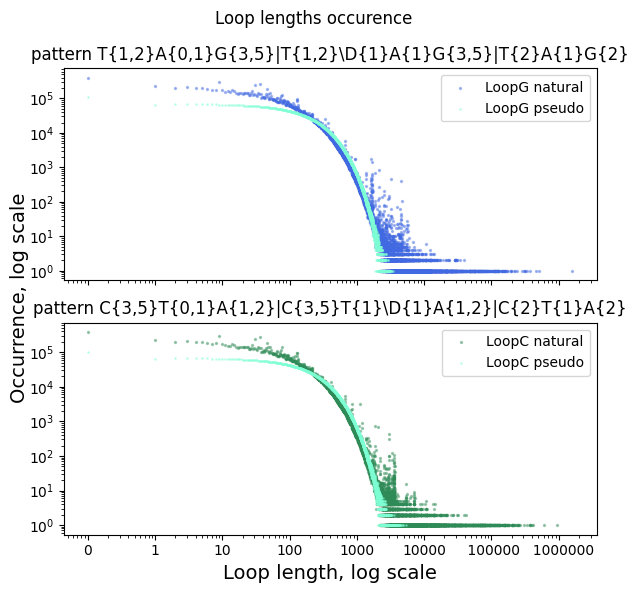

In [25]:
prediction = complete_prediction_multifasta(filename1, filename2, patternG_obj, patternC_obj)